# 07. Реальные данные «Рак груди» (569 опухолей): бинарная классификация и выбор порога

| | |
|---|---|
| **Уровень** | 2 из 4 — маленькие данные: реальные наборы и базовые приёмы (`2_small`) |
| **Скрипт-источник** | [`07_breast_cancer_classification.py`](../07_breast_cancer_classification.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 4 с |

**Цель.** Пройти задачу бинарной классификации от данных до решения с выбранным порогом.

### Чему вы научитесь

- Разбор набора и баланса классов
- ROC AUC и точность
- Матрица ошибок
- Почему порог 0.5 — не закон (пропустить злокачественную опухоль дороже)
- Сравнение с логистической регрессией

### Данные

`sklearn.datasets.load_breast_cancer` — 569 опухолей, 30 признаков (размер, форма, текстура ядер клеток по снимку), класс 1 — доброкачественная (357), 0 — злокачественная (212). Встроен в scikit-learn.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Сравнение по кросс-валидации (5 фолдов × 3 повтора)
3. **Этап 3.** LightGBM: обучение на 70%, проверка на 30%
4. **Этап 4.** Порог: пропуск злокачественной опухоли в 10 раз дороже ложной тревоги
5. **Этап 5.** Вывод

> Ноутбук собран из `examples/2_small/07_breast_cancer_classification.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "2_small/07_breast_cancer_classification.py", title="07. Реальные данные «Рак груди»: классификация и порог",
             goal="построить классификатор и выбрать порог по цене ошибок")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from gbcourse.style import ROLE
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Этап 1. Данные

In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target.to_numpy()
ex.describe(X, y, target="1 = доброкачественная", task="classification", source="sklearn.datasets.load_breast_cancer (Wisconsin)")

   Источник: sklearn.datasets.load_breast_cancer (Wisconsin)
   Объектов: 569   признаков: 30   память: 0.13 МБ
   Типы признаков: float64 × 30
   Пропусков нет
   Цель «1 = доброкачественная»: класс 0 — 212 (37.3%), класс 1 — 357 (62.7%)
   Первые строки:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,...,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,[1 = доброкачественная]
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,...,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,...,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,...,0.4245,0.4504,0.2430,0.3613,0.08758,0


## Этап 2. Сравнение по кросс-валидации (5 фолдов × 3 повтора)

In [3]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=0)
models = {"логистическая регрессия": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
          "LightGBM по умолчанию": lgb.LGBMClassifier(verbose=-1, random_state=0)}
auc = {}
for name, m in models.items():
    a = cross_val_score(m, X, y, cv=cv, scoring="roc_auc")
    acc = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    auc[name] = a.mean()
    print(f"   {name:24s} ROC AUC {a.mean():.4f} ± {a.std():.4f}, точность {acc.mean():.4f}")
ex.note("Обе модели почти безошибочны; логистическая регрессия не хуже — признаки хорошо разделяют классы и линейно.")

   логистическая регрессия  ROC AUC 0.9950 ± 0.0048, точность 0.9754

   LightGBM по умолчанию    ROC AUC 0.9934 ± 0.0055, точность 0.9672


> ▸ **Вывод.** Обе модели почти безошибочны; логистическая регрессия не хуже — признаки хорошо разделяют классы и линейно.

## Этап 3. LightGBM: обучение на 70%, проверка на 30%

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
m = lgb.LGBMClassifier(verbose=-1, random_state=0).fit(X_tr, y_tr)
p = m.predict_proba(X_te)[:, 1]
print(f"   ROC AUC на отложенных: {roc_auc_score(y_te, p):.4f}")
tn, fp, fn, tp = confusion_matrix(y_te, p > 0.5).ravel()
print(f"   порог 0.5: злокачественных пропущено (названы доброкачественными) — {fp}, ложных тревог — {fn}")

   ROC AUC на отложенных: 0.9873
   порог 0.5: злокачественных пропущено (названы доброкачественными) — 5, ложных тревог — 5


## Этап 4. Порог: пропуск злокачественной опухоли в 10 раз дороже ложной тревоги

   порог 0.5: цена 55 (пропусков 5, тревог 5)
   лучший порог 0.90: цена 29 (пропусков 2, тревог 9)


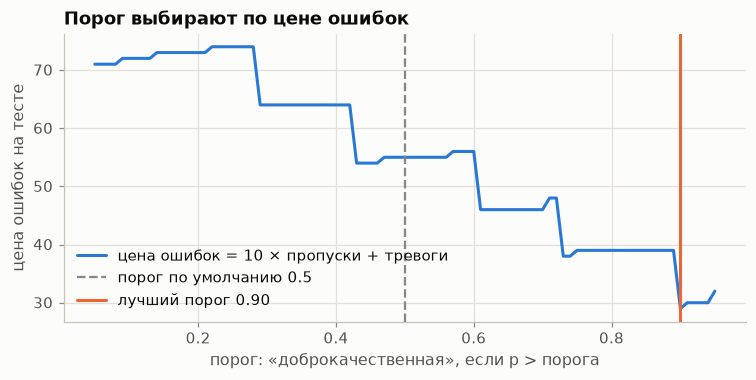

> ▸ **Вывод.** Порог выбирают по цене ошибок, а не по умолчанию. На честной задаче его подбирают на валидации, а не на тесте.

In [5]:
best, curve = None, []
for t in np.linspace(0.05, 0.95, 91):
    tn, fp, fn, tp = confusion_matrix(y_te, p > t).ravel()
    cost = 10 * fp + fn          # fp: злокачественная (0) названа доброкачественной (1)
    curve.append((t, cost))
    if best is None or cost < best[0]:
        best = (cost, t, fp, fn)
tn, fp5, fn5, tp = confusion_matrix(y_te, p > 0.5).ravel()
print(f"   порог 0.5: цена {10 * fp5 + fn5} (пропусков {fp5}, тревог {fn5})")
print(f"   лучший порог {best[1]:.2f}: цена {best[0]} (пропусков {best[2]}, тревог {best[3]})")
assert best[0] <= 10 * fp5 + fn5
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(*zip(*curve), color=ROLE["model"], lw=2, label="цена ошибок = 10 × пропуски + тревоги")
ax.axvline(0.5, color=ROLE["truth"], ls="--", lw=1.5, label="порог по умолчанию 0.5")
ax.axvline(best[1], color=ROLE["tree"], lw=2, label=f"лучший порог {best[1]:.2f}")
ax.set(xlabel="порог: «доброкачественная», если p > порога", ylabel="цена ошибок на тесте",
       title="Порог выбирают по цене ошибок")
ax.legend()
ex.finish(fig, "07_threshold_cost")
ex.note("Порог выбирают по цене ошибок, а не по умолчанию. На честной задаче его подбирают на валидации, а не на тесте.")

## Этап 5. Вывод

In [6]:
ex.note("""Модель — это ещё и порог: одна и та же вероятность ведёт к разным решениям при разной цене ошибок.
На 569 объектах и хорошо разделимых признаках бустинг не обязан обгонять логистическую регрессию.""")
ex.done()

> ▸ **Вывод.** Модель — это ещё и порог: одна и та же вероятность ведёт к разным решениям при разной цене ошибок. На 569 объектах и хорошо разделимых признаках бустинг не обязан обгонять логистическую регрессию.

Готово за 2.5 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Сделайте цену пропуска злокачественной опухоли 50 вместо 10 — какой порог станет лучшим?
2. Проверьте калибровку вероятностей LightGBM на этих данных (методы из примера 28).
3. Оставьте 5 самых важных признаков: сколько AUC потеряется?

## Что дальше

- **Теория в курсе:** [6 «Классификация»](../../../lessons/lesson_6/README.md), [13.2 «Калибровка и интервалы»](../../../lessons/lesson_13_2/README.md).
- **Предыдущий пример:** [06. Реальные данные «Диабет» (442 пациента): бустинг против простых моделей](06_diabetes_regression.ipynb)
- **Следующий пример:** [08. Функции потерь для регрессии: L2, L1, Хьюбер, квантиль — на данных с выбросами](08_loss_functions_outliers.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)